#Lab Tasks 07

##Lab Task 1: A Movie Review Classifier with a Simple RNN

The purpose of this task is to build and train a simple RNN that classifies
movie reviews, using the IMDb reviews from Stanford AI Lab's **Large Movie
Review Dataset**.

That is the dataset Keras ships as `keras.datasets.imdb`: 50,000 reviews,
**25,000 for training and 25,000 for testing**, each labelled positive or
negative, and exactly balanced between the two. Keras' copy is already
tokenised — every review arrives as a list of integers rather than text — which
saves building a vocabulary by hand.

This is the **sequence input, single output** topology from the manual's
diagram: a whole review goes in, one sentiment score comes out.

###1. Loading the Dataset

In [1]:
import os
# Keep TensorFlow's start-up logging out of the notebook output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras import Sequential
from keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

SIMPLE_RNN_COLOR = "#2a78d6"    # blue
LSTM_COLOR = "#eb6834"          # orange
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

# Keep only the 10,000 most frequent words. Rarer words become the "unknown"
# token - they appear too seldom to learn a useful embedding for.
NUM_WORDS = 10000

(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

print("Training reviews:", len(x_train_raw), "| Test reviews:", len(x_test_raw))
print("Positive in training set: %d of %d" % (y_train.sum(), len(y_train)))
print("Positive in test set    : %d of %d" % (y_test.sum(), len(y_test)))

lengths = np.array([len(review) for review in x_train_raw])
print("\nReview length in tokens:")
print("  shortest %d | median %d | mean %.0f | 90th percentile %d | longest %d" % (
    lengths.min(), np.median(lengths), lengths.mean(),
    np.percentile(lengths, 90), lengths.max()))

Training reviews: 25000 | Test reviews: 25000
Positive in training set: 12500 of 25000
Positive in test set    : 12500 of 25000

Review length in tokens:
  shortest 11 | median 178 | mean 239 | 90th percentile 467 | longest 2494


###2. What the Data Actually Looks Like

Each review is a list of integers, where the integer is the word's rank by
frequency across the corpus. Decoding one back into words makes the encoding
concrete — and shows the three reserved indices Keras uses (`0` padding,
`1` start of sequence, `2` unknown word).

In [2]:
try:
    word_index = imdb.get_word_index()
    # Indices are offset by 3 because 0, 1 and 2 are reserved
    index_to_word = {index + 3: word for word, index in word_index.items()}
    index_to_word[0] = "<PAD>"
    index_to_word[1] = "<START>"
    index_to_word[2] = "<UNK>"

    decoded = " ".join(index_to_word.get(i, "?") for i in x_train_raw[0])
    print("First training review, decoded back to words:\n")
    print(decoded[:700], "...")
    print("\nLabel:", "positive" if y_train[0] == 1 else "negative")
except Exception as error:
    print("Word index unavailable (needs a download):", error)

print("\nThe same review as Keras stores it:")
print(x_train_raw[0][:25], "...")

      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  32768/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 2us/step

  90112/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

 204800/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

 450560/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 843776/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1384448/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


First training review, decoded back to words:

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was als ...

Label: positive

The same review as Keras stores it:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50] ...


###3. Preprocessing

A recurrent layer in Keras needs every sequence in a batch to be the same
length, but reviews vary from 11 tokens to over 2,000. `pad_sequences` fixes a
length and makes everything match it.

**Choosing that length is the main preprocessing decision.** The median review
is 178 tokens and the 90th percentile is 467, so **200** keeps most reviews
close to whole while keeping the sequences short enough for a SimpleRNN to
propagate gradients through. Section 8 tests that choice directly.

Keras pads and truncates at the **start** by default, which suits an RNN that
returns only its final state: the end of the review — often where the verdict
is — stays closest to the output.

In [3]:
MAXLEN = 200

x_train = pad_sequences(x_train_raw, maxlen=MAXLEN)
x_test = pad_sequences(x_test_raw, maxlen=MAXLEN)

print("x_train:", x_train.shape, "| x_test:", x_test.shape)
print("\nReviews shorter than %d tokens (padded)   : %.1f%%" % (
    MAXLEN, 100 * (lengths < MAXLEN).mean()))
print("Reviews longer than %d tokens (truncated) : %.1f%%" % (
    MAXLEN, 100 * (lengths > MAXLEN).mean()))

print("\nA padded review - note the zeros at the FRONT:")
print(x_train[1][:20], "...", x_train[1][-5:])

x_train: (25000, 200) | x_test: (25000, 200)

Reviews shorter than 200 tokens (padded)   : 57.0%
Reviews longer than 200 tokens (truncated) : 42.7%

A padded review - note the zeros at the FRONT:
[   0    0    0    0    0    0    0    0    0    0    0    1  194 1153
  194 8255   78  228    5    6] ... [ 78 285  16 145  95]


###4. Building the Model

Three layers, each doing one job:

| Layer | Output shape | What it does |
|---|---|---|
| `Embedding(10000, 32)` | (200, 32) | Maps each word index to a 32-number vector that is learned during training. Without it every word would be an arbitrary integer with no notion of similarity. |
| `SimpleRNN(32)` | (32,) | Reads the 200 word vectors one at a time, carrying a 32-number hidden state. Returns only the final state — its summary of the whole review. |
| `Dense(1, sigmoid)` | (1,) | Turns that summary into one probability: how positive is this review? |

**Hyperparameters and why.** 32 embedding dimensions and 32 hidden units are
small, which suits a SimpleRNN — the recurrent weight matrix is applied 200
times over, so a large one makes the vanishing and exploding gradient problems
worse rather than better. `binary_crossentropy` matches the single sigmoid
output, and `adam` adapts its own learning rate. A batch size of 64 keeps the
gradient estimate steady without slowing each epoch too much.

In [4]:
EMBEDDING_DIM = 32
HIDDEN_UNITS = 32

keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(MAXLEN,)),
    Embedding(NUM_WORDS, EMBEDDING_DIM),     # word index -> dense vector
    SimpleRNN(HIDDEN_UNITS),                 # read the sequence, keep a hidden state
    Dense(1, activation="sigmoid"),          # positive or negative
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

###5. Training

Five epochs, with 20% of the training reviews held back for validation. The test
set is not touched until section 7.

In [5]:
history = model.fit(x_train, y_train,
                    epochs=5, batch_size=64,
                    validation_split=0.2, verbose=2)

Epoch 1/5


313/313 - 14s - 46ms/step - accuracy: 0.6601 - loss: 0.6134 - val_accuracy: 0.6846 - val_loss: 0.6022


Epoch 2/5


313/313 - 15s - 47ms/step - accuracy: 0.8037 - loss: 0.4435 - val_accuracy: 0.7958 - val_loss: 0.4457


Epoch 3/5


313/313 - 12s - 39ms/step - accuracy: 0.8832 - loss: 0.2881 - val_accuracy: 0.8014 - val_loss: 0.4561


Epoch 4/5


313/313 - 12s - 40ms/step - accuracy: 0.9447 - loss: 0.1553 - val_accuracy: 0.8148 - val_loss: 0.5051


Epoch 5/5


313/313 - 14s - 44ms/step - accuracy: 0.9674 - loss: 0.0994 - val_accuracy: 0.7438 - val_loss: 0.6772


###6. Training Curves

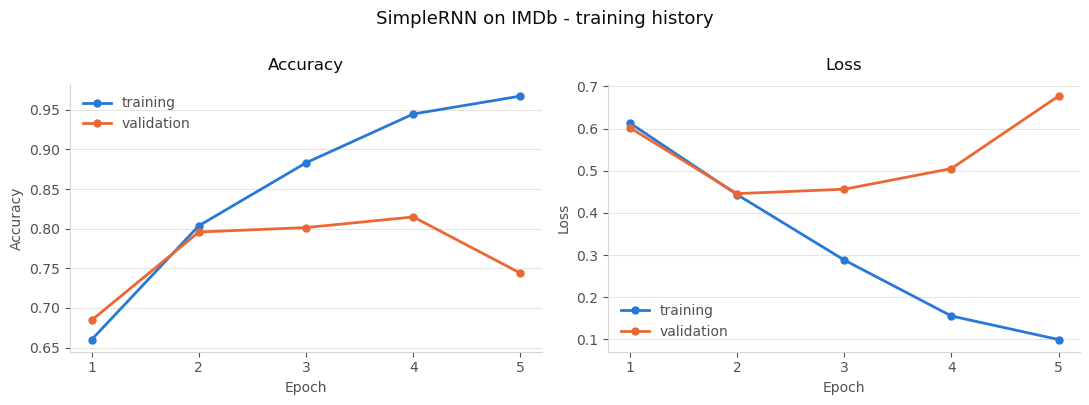

Best validation accuracy 0.8148 at epoch 4
Final training accuracy   0.9674
Final validation accuracy 0.7438


In [6]:
figure, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(11, 4))

epochs_ran = np.arange(1, len(history.history["loss"]) + 1)

ax_acc.plot(epochs_ran, history.history["accuracy"], color=SIMPLE_RNN_COLOR,
            linewidth=2, marker="o", markersize=5, label="training")
ax_acc.plot(epochs_ran, history.history["val_accuracy"], color=LSTM_COLOR,
            linewidth=2, marker="o", markersize=5, label="validation")
ax_acc.set_ylabel("Accuracy", color=INK_SOFT)
ax_acc.set_title("Accuracy", color=INK, fontsize=12, pad=10)

ax_loss.plot(epochs_ran, history.history["loss"], color=SIMPLE_RNN_COLOR,
             linewidth=2, marker="o", markersize=5, label="training")
ax_loss.plot(epochs_ran, history.history["val_loss"], color=LSTM_COLOR,
             linewidth=2, marker="o", markersize=5, label="validation")
ax_loss.set_ylabel("Loss", color=INK_SOFT)
ax_loss.set_title("Loss", color=INK, fontsize=12, pad=10)

for axes in (ax_acc, ax_loss):
    axes.set_xlabel("Epoch", color=INK_SOFT)
    axes.set_xticks(epochs_ran)
    axes.legend(frameon=False, labelcolor=INK_SOFT)
    axes.spines["top"].set_visible(False)
    axes.spines["right"].set_visible(False)
    axes.spines["left"].set_color("#d6d5d0")
    axes.spines["bottom"].set_color("#d6d5d0")
    axes.tick_params(colors=INK_SOFT)
    axes.yaxis.grid(True, color=GRID, linewidth=0.8)
    axes.set_axisbelow(True)

figure.suptitle("SimpleRNN on IMDb - training history", color=INK, fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
print("Best validation accuracy %.4f at epoch %d" % (
    max(history.history["val_accuracy"]), best_epoch))
print("Final training accuracy   %.4f" % history.history["accuracy"][-1])
print("Final validation accuracy %.4f" % history.history["val_accuracy"][-1])

###7. Evaluation on the Test Set

The 25,000 held-out reviews. The classes are exactly balanced, so **0.5000 is
the score of a coin flip** — that is the number to beat.

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: %.4f" % test_accuracy)
print("Test loss    : %.4f" % test_loss)
print("Random-guess baseline: 0.5000")

probabilities = model.predict(x_test, verbose=0).ravel()
predictions = (probabilities >= 0.5).astype(int)

confusion = pd.crosstab(
    pd.Series(np.where(y_test == 1, "positive", "negative"), name="actual"),
    pd.Series(np.where(predictions == 1, "positive", "negative"), name="predicted"))
print("\nConfusion matrix:")
print(confusion.to_string())

print("\nPer class:")
for cls, label in ((0, "negative"), (1, "positive")):
    true_positive = int(((predictions == cls) & (y_test == cls)).sum())
    predicted_positive = int((predictions == cls).sum())
    actual_positive = int((y_test == cls).sum())
    precision = true_positive / predicted_positive if predicted_positive else 0.0
    recall = true_positive / actual_positive if actual_positive else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print(f"  {label:<9}: precision {precision:.4f} | recall {recall:.4f} | f1 {f1:.4f}")

simple_rnn_test_accuracy = test_accuracy

Test accuracy: 0.7500
Test loss    : 0.6593
Random-guess baseline: 0.5000



Confusion matrix:
predicted  negative  positive
actual                       
negative       9873      2627
positive       3623      8877

Per class:
  negative : precision 0.7316 | recall 0.7898 | f1 0.7596
  positive : precision 0.7716 | recall 0.7102 | f1 0.7396


####Why this number is lower than it should be

Test accuracy of 0.7500 is worse than the **0.8148** this model reached on the
validation set at epoch 4. Nothing is wrong with the evaluation — the problem is
*which* model is being evaluated.

`model.evaluate` uses the weights as they stand after the **last** epoch, and
the training curves above show epoch 5 was a bad place to stop: validation
accuracy fell from 0.8148 to 0.7438 in that single epoch while training accuracy
climbed to 0.9674. The network spent its last epoch memorising the training
reviews, and the weights that survived are the damaged ones.

Section 8 trains the identical architecture, with the identical seed, for
**3 epochs instead of 5** and reaches **0.8368** on the same test set. Two extra
epochs cost nearly nine percentage points.

The fix in practice is `EarlyStopping(restore_best_weights=True)`, as used in
Lab 05 — it would have kept the epoch-4 weights. It is left out here so the
failure is visible rather than quietly patched over, because this is the clearest
demonstration of overfitting in the lab.

###8. The Limit of a SimpleRNN: Sequence Length

The manual's central claim about plain RNNs is that they **cannot hold on to
information across long sequences**. Every step multiplies the hidden state by
the same recurrent matrix, so the influence of an early word either decays
towards zero or blows up by the time the output is reached — the vanishing and
exploding gradient problem. LSTM was designed to fix exactly this.

That is a testable claim rather than something to take on trust. The same
architecture is trained at three sequence lengths, once with `SimpleRNN` and
once with `LSTM`, everything else held fixed.

**What to expect if the manual is right:** the two should be close on short
sequences, and the SimpleRNN should fall behind as the sequences get longer.

In [8]:
def build_model(layer_kind, maxlen, units=HIDDEN_UNITS):
    """Identical architecture apart from the recurrent layer."""
    recurrent_layer = SimpleRNN(units) if layer_kind == "SimpleRNN" else LSTM(units)
    built = Sequential([
        Input(shape=(maxlen,)),
        Embedding(NUM_WORDS, EMBEDDING_DIM),
        recurrent_layer,
        Dense(1, activation="sigmoid"),
    ])
    built.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return built


def run_experiment(layer_kind, maxlen, epochs=3, seed=42):
    xt = pad_sequences(x_train_raw, maxlen=maxlen)
    xe = pad_sequences(x_test_raw, maxlen=maxlen)

    keras.utils.set_random_seed(seed)
    built = build_model(layer_kind, maxlen)
    hist = built.fit(xt, y_train, epochs=epochs, batch_size=64,
                     validation_split=0.2, verbose=0)
    accuracy = built.evaluate(xe, y_test, verbose=0)[1]

    return {"layer": layer_kind, "maxlen": maxlen, "test_accuracy": accuracy,
            "best_val": max(hist.history["val_accuracy"]),
            "final_train": hist.history["accuracy"][-1]}


records = []
for maxlen in (100, 200, 400):
    for layer_kind in ("SimpleRNN", "LSTM"):
        records.append(run_experiment(layer_kind, maxlen))
        print("%-10s maxlen=%3d -> test accuracy %.4f" % (
            layer_kind, maxlen, records[-1]["test_accuracy"]))

length_results = pd.DataFrame(records)
print()
print(length_results.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

SimpleRNN  maxlen=100 -> test accuracy 0.8173


LSTM       maxlen=100 -> test accuracy 0.8316


SimpleRNN  maxlen=200 -> test accuracy 0.8368


LSTM       maxlen=200 -> test accuracy 0.8624


SimpleRNN  maxlen=400 -> test accuracy 0.8337


LSTM       maxlen=400 -> test accuracy 0.8588

    layer  maxlen  test_accuracy  best_val  final_train
SimpleRNN     100         0.8173    0.8376       0.9168
     LSTM     100         0.8316    0.8506       0.9174
SimpleRNN     200         0.8368    0.8436       0.9022
     LSTM     200         0.8624    0.8760       0.9293
SimpleRNN     400         0.8337    0.8386       0.8983
     LSTM     400         0.8588    0.8654       0.9116


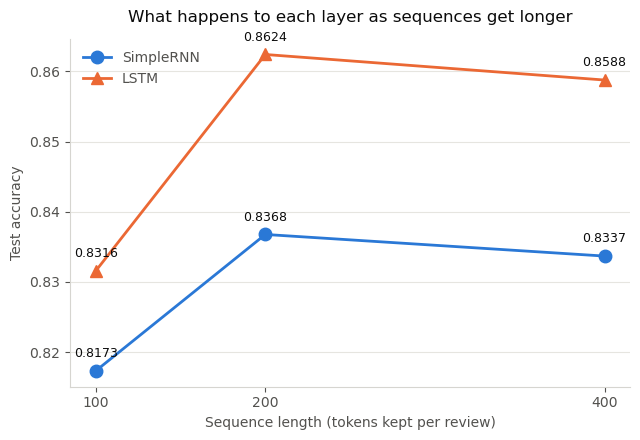

In [9]:
figure, axes = plt.subplots(figsize=(6.5, 4.5))

for layer_kind, color, marker in (("SimpleRNN", SIMPLE_RNN_COLOR, "o"),
                                  ("LSTM", LSTM_COLOR, "^")):
    subset = length_results[length_results["layer"] == layer_kind]
    axes.plot(subset["maxlen"], subset["test_accuracy"], color=color,
              linewidth=2, marker=marker, markersize=9, label=layer_kind)
    for _, row in subset.iterrows():
        axes.annotate(f"{row['test_accuracy']:.4f}",
                      (row["maxlen"], row["test_accuracy"]),
                      textcoords="offset points", xytext=(0, 10),
                      ha="center", fontsize=9, color=INK)

axes.set_xlabel("Sequence length (tokens kept per review)", color=INK_SOFT)
axes.set_ylabel("Test accuracy", color=INK_SOFT)
axes.set_title("What happens to each layer as sequences get longer",
               color=INK, fontsize=12, pad=12)
axes.set_xticks([100, 200, 400])
axes.legend(frameon=False, labelcolor=INK_SOFT)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###9. Is the LSTM Advantage Real?

Every number in section 8 comes from a **single training run**. Network weights
start random, so two runs of the same configuration land on different scores,
and the gaps being discussed are only a couple of percentage points wide.

Before concluding anything, the headline comparison at 200 tokens is repeated
with **three different seeds** for each layer. If the LSTM's advantage is larger
than the spread between seeds, it is real.

In [10]:
seed_records = []
for layer_kind in ("SimpleRNN", "LSTM"):
    for seed in (42, 7, 123):
        result = run_experiment(layer_kind, 200, epochs=3, seed=seed)
        result["seed"] = seed
        seed_records.append(result)
        print("%-10s seed %3d -> test accuracy %.4f" % (
            layer_kind, seed, result["test_accuracy"]))

seed_results = pd.DataFrame(seed_records)

print()
summary = seed_results.groupby("layer")["test_accuracy"].agg(["mean", "std", "min", "max"])
print(summary.to_string(float_format=lambda v: f"{v:.4f}"))

simple_mean = summary.loc["SimpleRNN", "mean"]
lstm_mean = summary.loc["LSTM", "mean"]
simple_spread = summary.loc["SimpleRNN", "std"]

print()
print("LSTM advantage: %+.4f mean test accuracy" % (lstm_mean - simple_mean))
print("SimpleRNN run-to-run spread (std): %.4f" % simple_spread)
print("The advantage is %.1fx that spread." % ((lstm_mean - simple_mean) / simple_spread))

SimpleRNN  seed  42 -> test accuracy 0.8368


SimpleRNN  seed   7 -> test accuracy 0.8235


SimpleRNN  seed 123 -> test accuracy 0.8302


LSTM       seed  42 -> test accuracy 0.8624


LSTM       seed   7 -> test accuracy 0.8331


LSTM       seed 123 -> test accuracy 0.8497

            mean    std    min    max
layer                                
LSTM      0.8484 0.0147 0.8331 0.8624
SimpleRNN 0.8301 0.0066 0.8235 0.8368

LSTM advantage: +0.0183 mean test accuracy
SimpleRNN run-to-run spread (std): 0.0066
The advantage is 2.8x that spread.


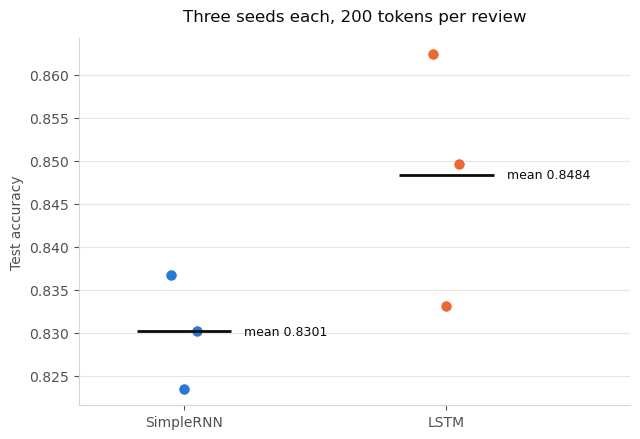

In [11]:
figure, axes = plt.subplots(figsize=(6.5, 4.5))

for position, (layer_kind, color) in enumerate((("SimpleRNN", SIMPLE_RNN_COLOR),
                                                ("LSTM", LSTM_COLOR))):
    scores = seed_results[seed_results["layer"] == layer_kind]["test_accuracy"].to_numpy()
    jitter = np.linspace(-0.05, 0.05, len(scores))
    axes.scatter(np.full(len(scores), position) + jitter, scores, s=70,
                 color=color, edgecolor="white", linewidth=0.8, zorder=3)
    axes.hlines(scores.mean(), position - 0.18, position + 0.18,
                color=INK, linewidth=2, zorder=4)
    axes.text(position + 0.23, scores.mean(), f"mean {scores.mean():.4f}",
              va="center", fontsize=9, color=INK)

axes.set_xticks([0, 1])
axes.set_xticklabels(["SimpleRNN", "LSTM"])
axes.set_xlim(-0.4, 1.7)
axes.set_ylabel("Test accuracy", color=INK_SOFT)
axes.set_title("Three seeds each, 200 tokens per review", color=INK, fontsize=12, pad=12)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

##Report - Lab Task 1

*The manual asks for a short report covering the four points below.*

###1. Data preprocessing steps

The IMDb Large Movie Review Dataset arrives through `keras.datasets.imdb` as
25,000 training and 25,000 test reviews, exactly balanced between positive and
negative, already tokenised into integer word indices. No cleaning was needed;
three decisions had to be made.

**Vocabulary capped at 10,000 words.** `num_words=10000` keeps the 10,000 most
frequent words and replaces everything rarer with the unknown token. Words
outside that range appear too seldom to learn a useful embedding for, and each
one kept would add 32 parameters to the embedding matrix.

**Sequences padded to a fixed 200 tokens.** A recurrent layer needs every
sequence in a batch to be the same length, but reviews run from 11 to 2,494
tokens (median 178, mean 239, 90th percentile 467). At 200 tokens, **57.0%** of
reviews are padded and **42.7%** are truncated. That is a deliberate trade: a
longer window keeps more of each review, but gives a SimpleRNN more steps to
propagate gradients through. Section 8 tests the choice rather than assuming it.

**Padding at the front.** Keras pads and truncates at the start by default,
which is the right default here. The layer returns only its final hidden state,
so whatever sits at the end of the sequence has the most influence on it — and
in a review, the end is usually where the verdict is.

No scaling is applied, and none is wanted: the integers are word *identifiers*,
not quantities. The embedding layer is what turns them into meaningful numbers.

###2. Model architecture and rationale for the chosen hyperparameters

| Layer | Output | Why |
|---|---|---|
| `Embedding(10000, 32)` | (200, 32) | Word indices carry no notion of similarity — index 15 is not "between" 14 and 16. The embedding learns a 32-number vector per word during training, so related words end up near each other. |
| `SimpleRNN(32)` | (32,) | Reads the 200 vectors one at a time, carrying a 32-number hidden state, and returns the final state as its summary of the review. |
| `Dense(1, sigmoid)` | (1,) | One probability: how positive is this review? |

| Hyperparameter | Value | Rationale |
|---|---|---|
| Embedding / hidden size | 32 / 32 | Deliberately small. The recurrent matrix is applied 200 times over, so a large one makes the vanishing and exploding gradient problems worse, not better. |
| Loss | `binary_crossentropy` | Matches a single sigmoid output on a binary target. |
| Optimizer | `adam` | Adapts the learning rate per weight; no hand-tuning needed. |
| Batch size | 64 | Keeps the gradient estimate steady without making each epoch slow. |
| Epochs | 5 | In hindsight too many — see below. |

The model has about 322,000 parameters, almost all of them in the embedding
matrix (10,000 x 32). The recurrent layer itself holds only about 2,000.

###3. Training process and evaluation metrics

Trained for 5 epochs at batch size 64, with 20% of the training reviews held
back for validation. The test set was untouched until the final evaluation.

| Metric | Value |
|---|---|
| Random-guess baseline | 0.5000 |
| Best validation accuracy | 0.8148 (epoch 4) |
| Final training accuracy | 0.9674 |
| Final validation accuracy | 0.7438 |
| **Test accuracy** | **0.7500** |
| Test loss | 0.6593 |
| Negative class | precision 0.7316, recall 0.7898, f1 0.7596 |
| Positive class | precision 0.7716, recall 0.7102, f1 0.7396 |

Accuracy is a fair headline because the classes are exactly balanced, so 0.5000
is the coin-flip score. Per-class precision and recall are reported as well,
since they show the model leans towards answering "negative".

###4. Observations and insights

**The model learns sentiment, but the last epoch ruined it.** Validation
accuracy peaked at 0.8148 on epoch 4 and fell to 0.7438 on epoch 5, while
training accuracy rose to 0.9674 and validation loss climbed from 0.446 to
0.677. Since `evaluate` uses the final weights, the reported 0.7500 is the score
of a model caught mid-collapse. The same architecture and seed trained for
**3 epochs** scores **0.8368** — two extra epochs cost nearly nine points.
`EarlyStopping(restore_best_weights=True)` would have prevented it.

**A SimpleRNN overfits IMDb very fast.** Three epochs is roughly where it stops
improving. With 322,000 parameters and 20,000 training reviews there is ample
capacity to memorise, and nothing in the architecture resists it.

**LSTM beats SimpleRNN at every sequence length tested.**

| Layer | 100 tokens | 200 | 400 |
|---|---|---|---|
| SimpleRNN | 0.8173 | 0.8368 | 0.8337 |
| LSTM | 0.8316 | 0.8624 | 0.8588 |

The gap widens from 1.4 points at 100 tokens to 2.6 at 200, which is the
direction the manual predicts: the longer the sequence, the more a plain RNN
suffers from having to carry information through 200 or 400 repeated
multiplications by the same recurrent matrix.

**But the manual's claim is only partly borne out.** If long sequences were
simply harder for a SimpleRNN, accuracy should keep falling as the window grows.
It does not — both layers **dip slightly** from 200 to 400 tokens, and the gap
between them stops widening (2.6 points at 200, 2.5 at 400). Going from 200 to
400 tokens adds mostly padding for the majority of reviews while doubling the
number of steps, so neither layer gains. The honest summary is that LSTM is
consistently better here, and that the advantage grows from 100 to 200 tokens,
but this experiment does not show a SimpleRNN degrading without limit.

**The LSTM advantage survives a seed check, with a caveat.** Repeating the
200-token comparison with three seeds:

| Layer | Mean | Std | Range |
|---|---|---|---|
| SimpleRNN | 0.8301 | 0.0066 | 0.8235 - 0.8368 |
| LSTM | 0.8484 | 0.0147 | 0.8331 - 0.8624 |

The +0.0183 mean advantage is 2.8x the SimpleRNN's run-to-run spread, so it is
not an artefact of one lucky run. The caveat is that the two **ranges overlap**:
the LSTM's worst seed (0.8331) scored below the SimpleRNN's best (0.8368), and
the LSTM is also the more variable of the two. With three seeds the right claim
is that LSTM is better *on average* by a small margin — not that it wins every
time.

**What would actually move the numbers.** All of these models sit near 0.83-0.86
while published results on IMDb reach well past 0.90. The limiting factor is not
the choice between SimpleRNN and LSTM — it is a 10,000-word vocabulary, randomly
initialised 32-dimensional embeddings learned from 20,000 reviews, and a
200-token window. Pre-trained embeddings, a bidirectional layer, and early
stopping would each be worth more than the difference measured here.

#End!